In [31]:
import pandas as pd
from wordcloud import WordCloud
import numpy as np
import tensorflow as tf
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import umap


from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
tag_embeddings = pd.read_parquet("input/tag_embeddings.parquet").values
tag_embeddings

array([[ 2.91517749e-03, -1.21673872e-03, -3.96054471e-03, ...,
        -5.74002136e-03, -2.47626612e-03, -7.76558882e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [3]:
embedding_dim = tag_embeddings.shape[1]  # จำนวนมิติของ embedding
latent_dim = 10  # ลดให้เหลือ 10 มิติ

input_layer = Input(shape=(embedding_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(latent_dim, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(embedding_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

In [ ]:
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [ ]:
autoencoder.fit(tag_embeddings, tag_embeddings, epochs=50, batch_size=256, shuffle=True)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2491  
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2437
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - loss: 0.2313
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - loss: 0.2045
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1516 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0729 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0148 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0013 
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - loss: 1.4445e-04
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.4964e-05
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - loss: 1.6116e-05
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0861e-05 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - loss: 9.0312e-06
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.1411e-06 
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5417e-06 
Ep

In [6]:
embedded_data = encoder.predict(tag_embeddings)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step


/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (13) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (13) found smaller than n_clusters (16). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (13) found smaller than n_clusters (17). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib

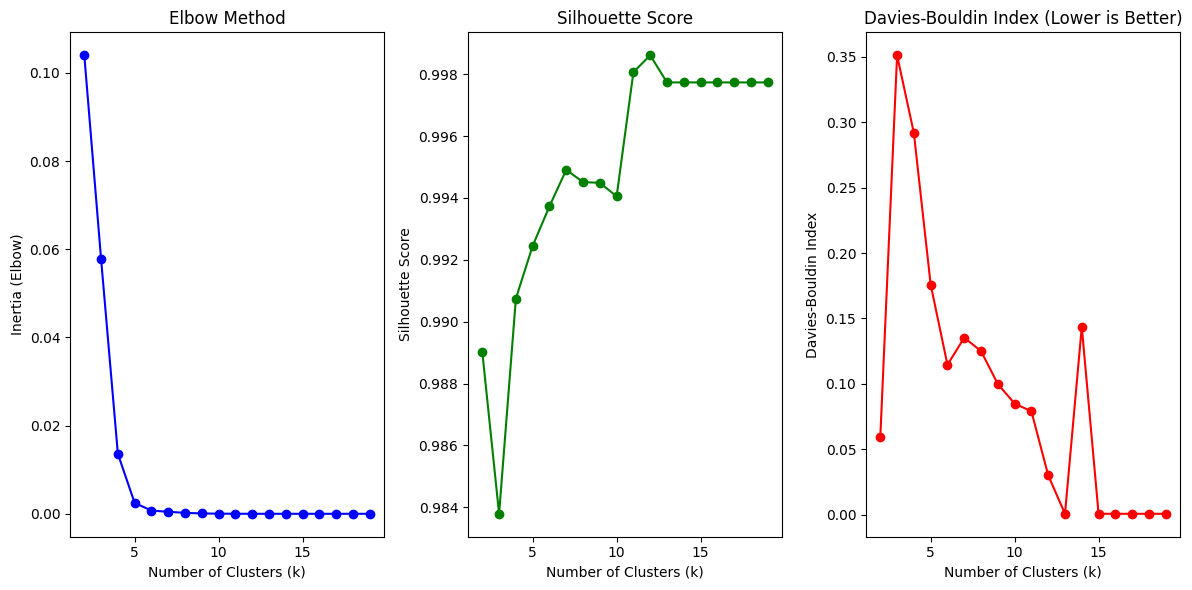

✅ Optimal number of clusters (k): 13
   - Silhouette Score: 0.9977
   - Elbow (Inertia): 0.0000
   - Davies-Bouldin Index: 0.0009


In [48]:
cluster_range = range(2, 20)

# Store scores
inertia_values = []  # Elbow Method
silhouette_scores = []  # Silhouette Score
dbi_scores = []  # Davies-Bouldin Index

# Compute metrics for each `k`
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embedded_data)
    
    # Inertia (Elbow)
    inertia_values.append(kmeans.inertia_)
    
    # Silhouette Score (Higher is better)
    silhouette_scores.append(silhouette_score(embedded_data, cluster_labels))
    
    # Davies-Bouldin Index (Lower is better)
    dbi_scores.append(davies_bouldin_score(embedded_data, cluster_labels))

# Normalize scores (since they have different ranges)
scaler = MinMaxScaler()

inertia_scaled = scaler.fit_transform(np.array(inertia_values).reshape(-1, 1)).flatten()
silhouette_scaled = scaler.fit_transform(np.array(silhouette_scores).reshape(-1, 1)).flatten()
dbi_scaled = scaler.fit_transform(np.array(dbi_scores).reshape(-1, 1)).flatten()

# Compute final score (higher is better)
final_scores = silhouette_scaled - inertia_scaled - dbi_scaled

# Find the best k (highest final score)
best_k_index = np.argmax(final_scores)

best_k = cluster_range[best_k_index]

# 🔹 Step 2: Plot the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.plot(cluster_range, inertia_values, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Elbow)')
plt.title('Elbow Method')

plt.subplot(1, 3, 2)
plt.plot(cluster_range, silhouette_scores, marker='o', linestyle='-', color='g')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.subplot(1, 3, 3)
plt.plot(cluster_range, dbi_scores, marker='o', linestyle='-', color='r')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index (Lower is Better)')

plt.tight_layout()
plt.show()

# Print best k
print(f"✅ Optimal number of clusters (k): {best_k}")
print(f"   - Silhouette Score: {silhouette_scores[best_k_index]:.4f}")
print(f"   - Elbow (Inertia): {inertia_values[best_k_index]:.4f}")
print(f"   - Davies-Bouldin Index: {dbi_scores[best_k_index]:.4f}")

In [33]:
n_clusters = 13  # จำนวน cluster ที่ต้องการ
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embedded_data)

In [34]:
cluster_centers = kmeans.cluster_centers_

In [35]:
def target_distribution(q):
    """ คำนวณ Soft Cluster Assignment Distribution """
    p = q ** 2 / tf.reduce_sum(q, axis=0)
    return (p / tf.reduce_sum(p, axis=1, keepdims=True))

In [36]:
class ClusteringLayer(Layer):
    """ Custom KMeans Clustering Layer """
    def __init__(self, n_clusters, cluster_centers, **kwargs):
        super(ClusteringLayer, self).__init__(**kwargs)
        self.n_clusters = n_clusters
        self.cluster_centers = tf.Variable(initial_value=cluster_centers, dtype=tf.float32, trainable=True)

    def call(self, inputs):
        q = 1.0 / (1.0 + tf.reduce_sum(tf.square(tf.expand_dims(inputs, axis=1) - self.cluster_centers), axis=2))
        q = tf.pow(q, (1.0 + 1.0) / 2.0)
        q = q / tf.reduce_sum(q, axis=1, keepdims=True)
        return q

In [ ]:
class DECModel(tf.keras.Model):
    def __init__(self, encoder, n_clusters, cluster_centers):
        super(DECModel, self).__init__()
        self.encoder = encoder
        self.clustering_layer = ClusteringLayer(n_clusters, cluster_centers)

    def call(self, inputs):
        z = self.encoder(inputs)
        q = self.clustering_layer(z)
        return q

In [38]:
dec_model = DECModel(encoder, n_clusters, cluster_centers)
optimizer = Adam(learning_rate=0.001)

In [39]:
batch_size = 256
epochs = 50

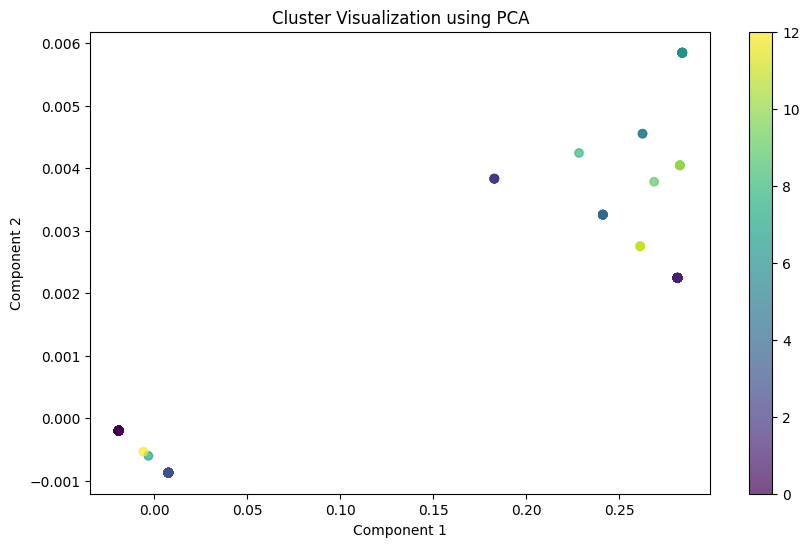

In [40]:
def plot_clusters(data, labels, method="PCA"):
    if method == "PCA":
        reducer = PCA(n_components=2)
    elif method == "t-SNE":
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    
    reduced_data = reducer.fit_transform(data)
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter)
    plt.title(f"Cluster Visualization using {method}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

# Plot using PCA
plot_clusters(embedded_data, clusters, method="PCA")

In [41]:
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        q = dec_model(tag_embeddings)
        p = target_distribution(q)
        loss = tf.reduce_mean(tf.keras.losses.KLDivergence()(p, q))
    
    grads = tape.gradient(loss, dec_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, dec_model.trainable_variables))
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")
        
final_clusters = np.argmax(dec_model(tag_embeddings), axis=1)


Epoch 0, Loss: 1.0453235290697194e-06
Epoch 5, Loss: 8.570395948481746e-07
Epoch 10, Loss: 6.942992172298545e-07
Epoch 15, Loss: 1.3964921663500718e-07
Epoch 20, Loss: 9.198718942116102e-08
Epoch 25, Loss: 1.4394235847703385e-07
Epoch 30, Loss: 1.4691008232148306e-07
Epoch 35, Loss: 1.4148105265121558e-07
Epoch 40, Loss: 6.9773440358744665e-09
Epoch 45, Loss: -1.0875110945107735e-07


In [42]:
clustered_df = pd.DataFrame({
    "Cluster": final_clusters
})

In [43]:
clustered_df

,Cluster
0,6
1,6
2,6
3,6
4,6
...,...
1761,6
1762,6
1763,6
1764,6


In [46]:
clustered_df[clustered_df['Cluster'] != 6]

,Cluster
